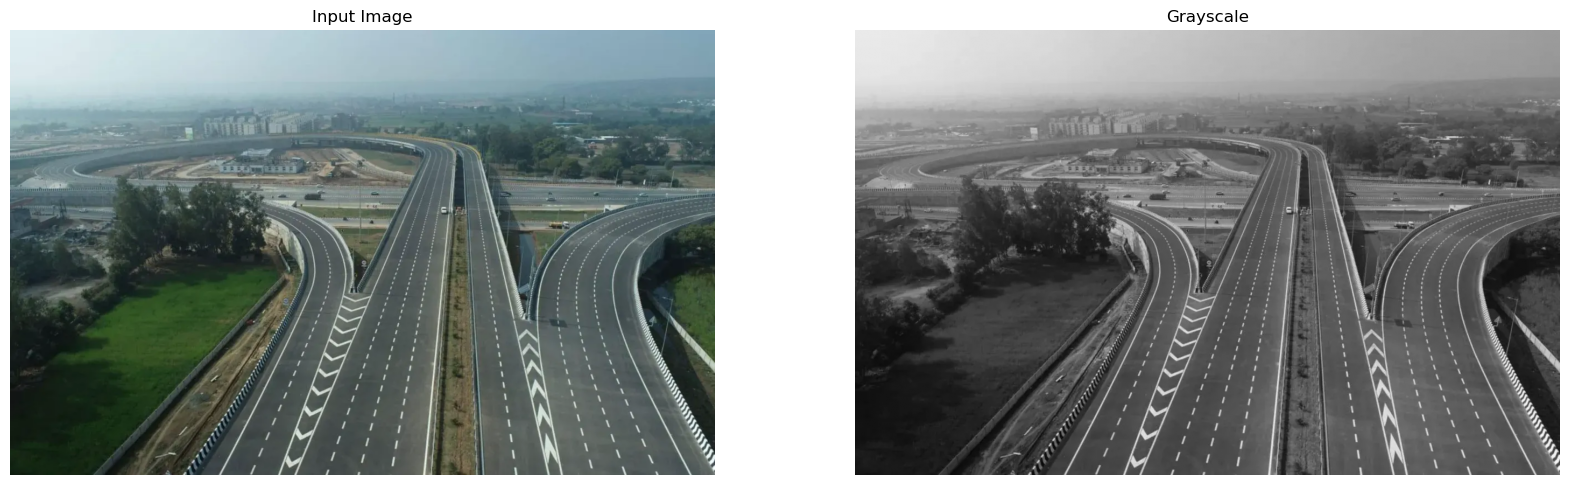

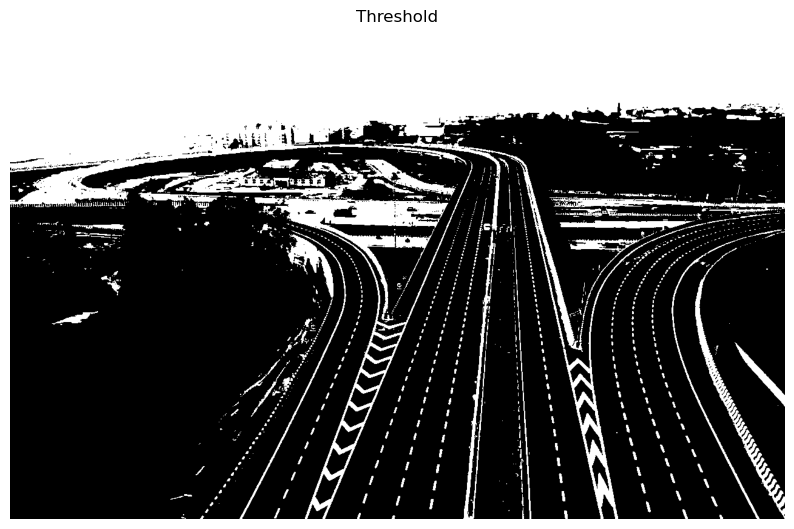

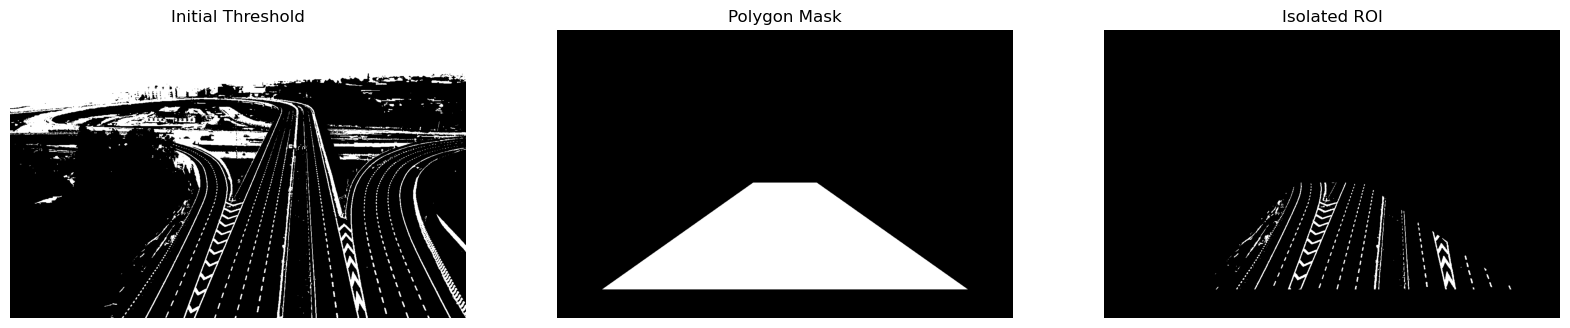

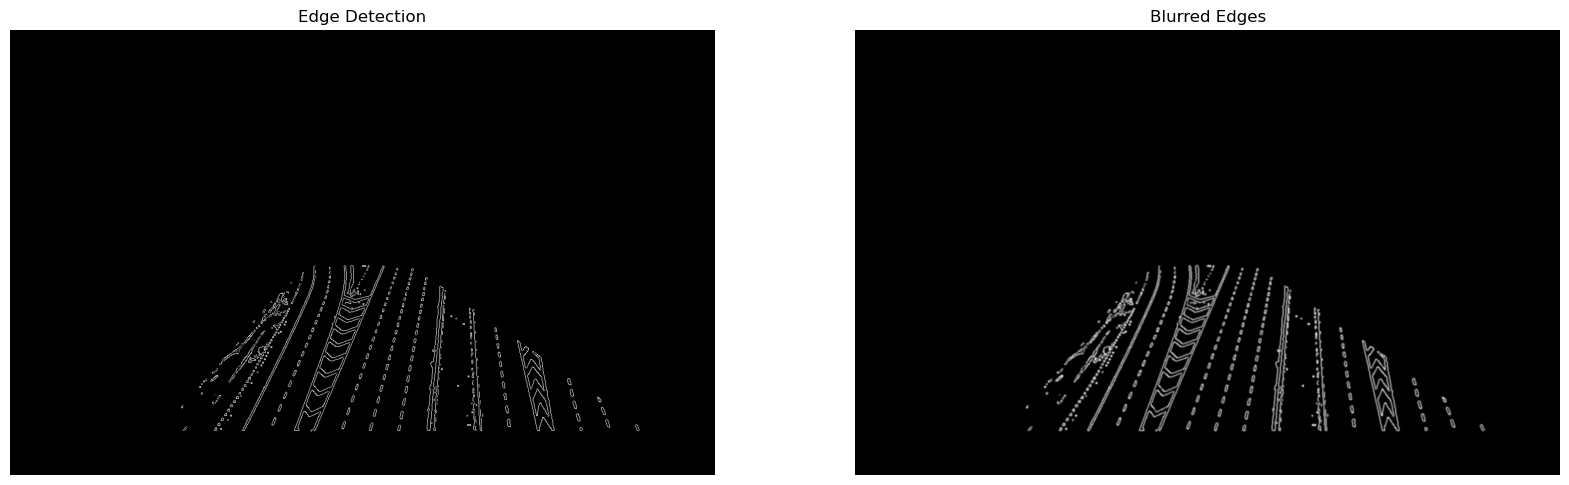

Hough line array shape: (432, 4)
Found 432 lines, including: [757 727 774 492]


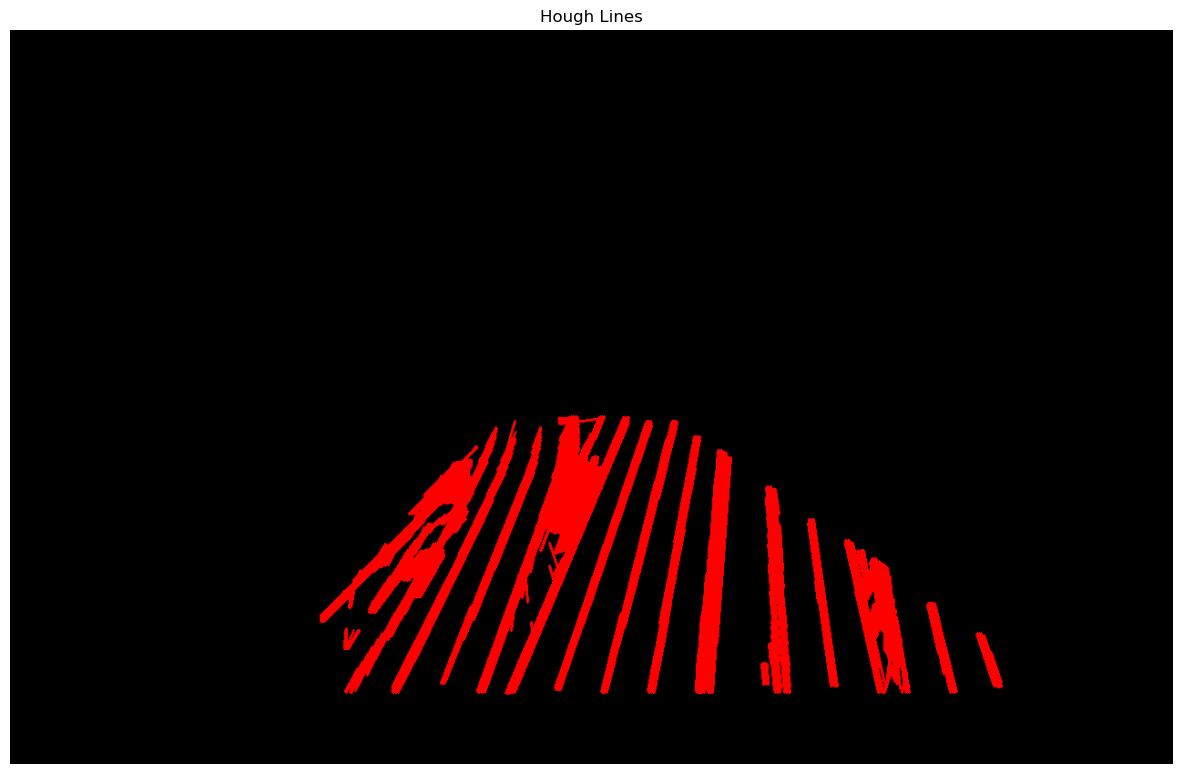

Left lane lines detected: 312
Right lane lines detected: 113
Left lane: [640, 725, 719, 427]
Right lane: [912, 725, 879, 427]


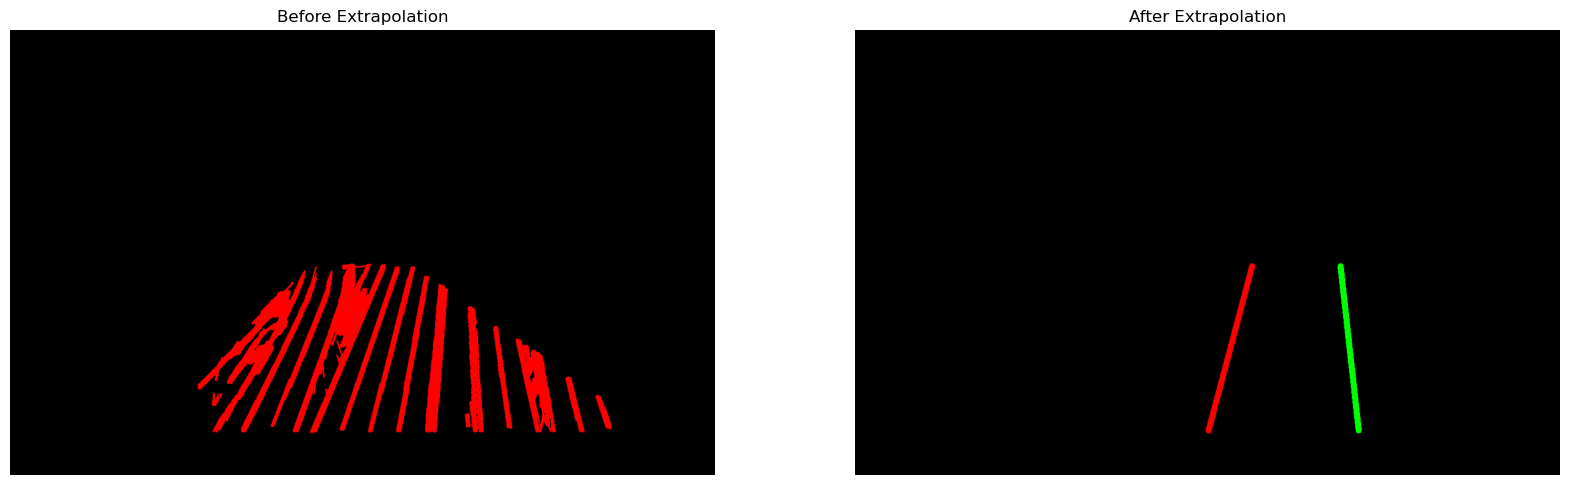

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('road.jpg')

# Check whether image was loaded successfully
if img is None:
    raise FileNotFoundError(
        "Could not find 'road.jpg'. Make sure the image is in the same folder as this notebook."
    )

# Convert BGR to RGB for Matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.show()

threshold_value = 120

_, threshold = cv2.threshold(
    gray,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)


# Display threshold image
plt.figure(figsize=(10, 8))
plt.imshow(threshold, cmap='gray')
plt.title('Threshold')
plt.axis('off')
plt.show()

# Get image dimensions
height, width = threshold.shape

# Define ROI dynamically based on image size
roi_vertices = np.array([[
    [int(width * 0.10), int(height * 0.90)],
    [int(width * 0.90), int(height * 0.90)],
    [int(width * 0.57), int(height * 0.53)],
    [int(width * 0.43), int(height * 0.53)]
]], dtype=np.int32)


# Create blank mask
mask = np.zeros_like(threshold)


# Since threshold is grayscale, use 255
ignore_mask_color = 255


# Fill polygon
cv2.fillPoly(
    mask,
    roi_vertices,
    ignore_mask_color
)


# Create ROI
roi = cv2.bitwise_and(
    threshold,
    mask
)


# Display ROI results
plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plt.imshow(threshold, cmap='gray')
plt.title('Initial Threshold')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title('Polygon Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(roi, cmap='gray')
plt.title('Isolated ROI')
plt.axis('off')

plt.show()

edges = cv2.Canny(
    roi,
    50,
    150
)


# Gaussian blur
canny_blur = cv2.GaussianBlur(
    edges,
    (5, 5),
    0
)


# Display edge detection
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_blur, cmap='gray')
plt.title('Blurred Edges')
plt.axis('off')

plt.show()

def draw_lines(img, lines, color=(255, 0, 0), thickness=2):
    """
    Draw detected lines on an image.

    Lines are converted to shape (N, 4)
    to avoid unpacking errors.
    """

    if lines is None:
        return

    # Convert to NumPy array
    lines = np.asarray(lines)

    # Convert to shape (N, 4)
    lines = lines.reshape(-1, 4)

    # Draw every line
    for x1, y1, x2, y2 in lines:

        cv2.line(
            img,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            color,
            thickness
        )


rho = 1
theta = np.pi / 180

threshold_hough = 20
min_line_length = 20
max_line_gap = 10


lines = cv2.HoughLinesP(
    canny_blur,
    rho,
    theta,
    threshold_hough,
    minLineLength=min_line_length,
    maxLineGap=max_line_gap
)


if lines is not None:

    # Convert from:
    # (N, 1, 4)
    #
    # to:
    # (N, 4)

    lines = lines.reshape(-1, 4)

    print("Hough line array shape:", lines.shape)

else:

    print("No Hough lines were detected.")


hough = np.zeros(
    (img.shape[0], img.shape[1], 3),
    dtype=np.uint8
)


draw_lines(
    hough,
    lines,
    color=(255, 0, 0),
    thickness=2
)


# Print detected lines safely
if lines is not None and len(lines) > 0:

    print(
        "Found {} lines, including: {}".format(
            len(lines),
            lines[0]
        )
    )

else:

    print("Found 0 lines.")


# Display Hough lines
plt.figure(figsize=(15, 10))

plt.imshow(hough)
plt.title('Hough Lines')
plt.axis('off')

plt.show()


def separate_left_right_lines(lines):
    """
    Separate lines into left and right lanes
    based on their slope.
    """

    left_lines = []
    right_lines = []

    if lines is None:
        return left_lines, right_lines

    # Make sure shape is (N, 4)
    lines = np.asarray(lines).reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        # Avoid division by zero
        if x2 - x1 == 0:
            continue

        # Calculate slope
        slope = (y2 - y1) / (x2 - x1)

        # Negative slope = left lane
        if slope < -0.5:

            left_lines.append(
                [x1, y1, x2, y2]
            )

        # Positive slope = right lane
        elif slope > 0.5:

            right_lines.append(
                [x1, y1, x2, y2]
            )

    return left_lines, right_lines



def cal_avg(values):

    if values is not None and len(values) > 0:

        return sum(values) / len(values)

    return 0


def extrapolate_lines(lines, upper_border, lower_border):
    """
    Extrapolate multiple detected lines into
    one average lane line.
    """

    slopes = []
    consts = []

    if lines is not None and len(lines) > 0:

        for x1, y1, x2, y2 in lines:

            # Avoid vertical lines
            if x2 - x1 == 0:
                continue

            # Calculate slope
            slope = (y2 - y1) / (x2 - x1)

            slopes.append(slope)

            # Equation:
            # y = mx + c
            c = y1 - slope * x1

            consts.append(c)


    # If no valid lines were found
    if len(slopes) == 0 or len(consts) == 0:

        return [
            0,
            lower_border,
            0,
            upper_border
        ]


    # Calculate average slope and intercept
    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)


    # Avoid division by zero
    if avg_slope == 0:

        return [
            0,
            lower_border,
            0,
            upper_border
        ]


    # Calculate lower intersection
    x_lane_lower_point = int(
        (lower_border - avg_consts) / avg_slope
    )


    # Calculate upper intersection
    x_lane_upper_point = int(
        (upper_border - avg_consts) / avg_slope
    )


    return [
        x_lane_lower_point,
        lower_border,
        x_lane_upper_point,
        upper_border
    ]



roi_upper_border = int(height * 0.53)
roi_lower_border = int(height * 0.90)



lanes_img = np.zeros(
    (img.shape[0], img.shape[1], 3),
    dtype=np.uint8
)


lines_left, lines_right = separate_left_right_lines(
    lines
)


print(
    "Left lane lines detected:",
    len(lines_left)
)

print(
    "Right lane lines detected:",
    len(lines_right)
)


lane_left = extrapolate_lines(
    lines_left,
    roi_upper_border,
    roi_lower_border
)


lane_right = extrapolate_lines(
    lines_right,
    roi_upper_border,
    roi_lower_border
)


print("Left lane:", lane_left)
print("Right lane:", lane_right)


draw_lines(
    lanes_img,
    [lane_left],
    color=(255, 0, 0),
    thickness=10
)


draw_lines(
    lanes_img,
    [lane_right],
    color=(0, 255, 0),
    thickness=10
)



fig = plt.figure(figsize=(20, 10))


ax = fig.add_subplot(1, 2, 1)

ax.imshow(hough)

ax.set_title(
    'Before Extrapolation'
)

ax.axis('off')


ax = fig.add_subplot(1, 2, 2)

ax.imshow(lanes_img)

ax.set_title(
    'After Extrapolation'
)

ax.axis('off')


plt.show()